In [1]:
# Imports
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from config.settings import SILVER_DIR

import pandas as pd
import matplotlib.pyplot as plt
from data.timetable import (
    load_bronze,
    build_planned_timetable,
    add_segment_type,
    add_dynamics,
    add_time_in_seconds,
    add_period,
    assign_platforms,
    save_gold,
    load_gold,
    add_train_type
)

In [2]:
# Load bronze data
months = [
    '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512',
    '202601', '202602'
]
df = load_bronze(months)
print(f"Loaded: {len(df)} rows, {df['TRAIN_NO'].nunique()} trains")

Loaded: 2847682 rows, 1367 trains


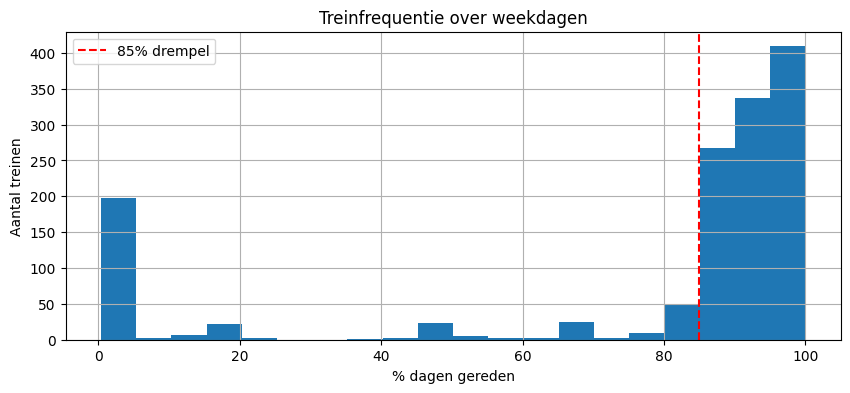

Treinen boven 85% drempel: 1028
Treinen onder 85% drempel: 339


In [3]:
train_counts = df.groupby('TRAIN_NO')['DATDEP'].nunique().reset_index()
train_counts.columns = ['TRAIN_NO', 'DAYS']
total_days = df['DATDEP'].nunique()
train_counts['PERCENTAGE'] = (train_counts['DAYS'] / total_days) * 100

train_counts['PERCENTAGE'].hist(bins=20, figsize=(10, 4))
plt.xlabel('% dagen gereden')
plt.ylabel('Aantal treinen')
plt.title('Treinfrequentie over weekdagen')
plt.axvline(x=85, color='red', linestyle='--', label='85% drempel')
plt.legend()
plt.show()

print(f"Treinen boven 85% drempel: {(train_counts['PERCENTAGE'] >= 85).sum()}")
print(f"Treinen onder 85% drempel: {(train_counts['PERCENTAGE'] < 85).sum()}")

## Checkpoint

`build_planned_timetable` itereert over alle 1367 treinen en vergelijkt timetable-varianten via `.equals()` — dit duurt enkele minuten. Het checkpoint slaat het ruwe resultaat op als parquet zodat je bij herwerking van latere stappen (segmenttype, platforms, ...) niet telkens opnieuw hoeft te builden.

**Cel 5 runnen** — enkel als de brondata of `build_planned_timetable` zelf gewijzigd is.  
**Cel 6 runnen** — altijd, bij elke herstart van de notebook.



In [4]:
# Bouw timetable en sla checkpoint op (enkel runnen als data verandert)
timetable = build_planned_timetable(df, min_frequency=0.85)
print(f"Trains after frequency filter: {timetable['TRAIN_NO'].nunique()}")

# Checkpoint opslaan — VOOR add_segment_type en assign_platforms
SILVER_DIR.mkdir(parents=True, exist_ok=True)
timetable.to_parquet(SILVER_DIR / 'timetable_raw.parquet', index=False)
print("Checkpoint opgeslagen.")

Trains after frequency filter: 1028
Checkpoint opgeslagen.


In [5]:
# Laad checkpoint (snel, gebruik dit altijd)
timetable = pd.read_parquet(SILVER_DIR / 'timetable_raw.parquet')
print(f"Geladen: {timetable['TRAIN_NO'].nunique()} treinen")
print(f"Kolommen: {timetable.columns.tolist()}")

Geladen: 1028 treinen
Kolommen: ['SECTION', 'SOURCE', 'TARGET', 'PLANNED_DEPARTURE', 'PLANNED_ARRIVAL', 'RELATION_DIRECTION', 'TRAIN_NO']


In [6]:
# Tijdsconventie na stap 3:
#   ENTRY_SECONDS = A_t,s = moment binnenkomst segment (vroeger)
#   EXIT_SECONDS  = D_t,s = moment verlaten segment    (later)
#   → altijd ENTRY_SECONDS < EXIT_SECONDS

timetable = add_segment_type(timetable)
timetable = add_dynamics(timetable)
timetable = add_period(timetable)
timetable = add_time_in_seconds(timetable) # nodig voor assign_platforms, save_gold dropt deze kolommen nadien
timetable = add_train_type(timetable) 
timetable, diagnostics = assign_platforms(timetable)

BRUSSEL-NOORD (alle): 477 ongeldige intervallen (EXIT_SECONDS <= ENTRY_SECONDS) — worden overgeslagen
BRUSSEL-CENTRAAL (alle): 947 ongeldige intervallen (EXIT_SECONDS <= ENTRY_SECONDS) — worden overgeslagen
BRUSSEL-CONGRES (alle): 64 ongeldige intervallen (EXIT_SECONDS <= ENTRY_SECONDS) — worden overgeslagen
BRUSSEL-KAPELLEKERK (alle): 32 ongeldige intervallen (EXIT_SECONDS <= ENTRY_SECONDS) — worden overgeslagen


## Timetable overzicht

In [7]:
# Dynamiek verdeling
print(timetable['DYNAMICS'].value_counts())

DYNAMICS
0-0       4746
ACC-0     3329
0-BR      1724
ACC-BR    1155
Name: count, dtype: int64


In [8]:
# Periode verdeling
print(timetable['PERIOD'].value_counts())

PERIOD
DAYTIME         4428
EVENING         2453
EVENING PEAK    1876
MORNING PEAK    1812
NIGHT            385
Name: count, dtype: int64


In [9]:
# Overzicht kolommen en datatypes
print(timetable.dtypes)
print(f"\nTotaal rijen: {len(timetable)}")
print(f"Totaal treinen: {timetable['TRAIN_NO'].nunique()}")
print(f"Totaal unieke secties: {timetable['SECTION'].nunique()}")

SECTION                          str
SOURCE                           str
TARGET                           str
PLANNED_DEPARTURE     datetime64[us]
PLANNED_ARRIVAL       datetime64[us]
RELATION_DIRECTION               str
TRAIN_NO                       int64
TYPE                             str
DYNAMICS                         str
PERIOD                           str
ENTRY_SECONDS                float64
EXIT_SECONDS                 float64
TRAIN_TYPE                       str
SECTION_MACRO                    str
dtype: object

Totaal rijen: 10954
Totaal treinen: 1028
Totaal unieke secties: 178


## Validatie

In [10]:
# Valideer één trein visueel
train_no = timetable['TRAIN_NO'].iloc[0]
timetable[timetable['TRAIN_NO'] == train_no][
    ['TRAIN_NO', 'SOURCE', 'TARGET', 'SECTION',
     'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS', 'PERIOD', 'DYNAMICS']
]

,TRAIN_NO,SOURCE,TARGET,SECTION,TYPE,ENTRY_SECONDS,EXIT_SECONDS,PERIOD,DYNAMICS
0,10,SCHAARBEEK,BRUSSEL-NOORD,36N:SCHAARBEEK-BRUSSEL-NOORD,SOURCE,60300.0,60480.0,EVENING,ACC-BR
1,10,SCHAARBEEK,SCHAARBEEK,SCHAARBEEK -- ICE: FRANKFURT(MAIN) HBF -> BRUS...,WITHIN-STATION-DWELL,60480.0,60600.0,EVENING,ACC-0
2,10,BRUSSEL-NOORD,BRUSSEL-CONGRES,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BETWEEN-STATION,60600.0,60720.0,EVENING,ACC-0
3,10,BRUSSEL-NOORD,BRUSSEL-NOORD,BRUSSEL-NOORD,WITHIN-STATION-PASSING,60720.0,60720.0,EVENING,0-0
4,10,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BETWEEN-STATION,60720.0,60780.0,EVENING,0-0
5,10,BRUSSEL-CONGRES,BRUSSEL-CONGRES,BRUSSEL-CONGRES,WITHIN-STATION-PASSING,60780.0,60780.0,EVENING,0-0
6,10,BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,BETWEEN-STATION,60780.0,60900.0,EVENING,0-0
7,10,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,WITHIN-STATION-PASSING,60900.0,60900.0,EVENING,0-0
8,10,BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,BETWEEN-STATION,60900.0,61020.0,EVENING,0-0


In [11]:
# Valideer segmenttypes
print(timetable['TYPE'].value_counts())

TYPE
BETWEEN-STATION           4522
WITHIN-STATION-DWELL      2879
WITHIN-STATION-PASSING    2525
SOURCE                    1028
Name: count, dtype: int64


In [12]:
# Valideer dat ENTRY_SECONDS monotoon stijgt per trein
niet_monotoon = (
    timetable
    .sort_values(['TRAIN_NO', 'ENTRY_SECONDS'])
    .groupby('TRAIN_NO')['ENTRY_SECONDS']
    .apply(lambda x: (x.diff().dropna() < 0).any())
)
treinen_niet_monotoon = niet_monotoon[niet_monotoon].index.tolist()

print(f"Treinen met niet-monotone ENTRY_SECONDS: {len(treinen_niet_monotoon)}")
if treinen_niet_monotoon:
    for t in treinen_niet_monotoon[:5]:
        print(f"\nTrein {t}:")
        print(timetable[timetable['TRAIN_NO'] == t][
            ['SOURCE', 'TARGET', 'TYPE', 'ENTRY_SECONDS', 'EXIT_SECONDS']
        ].to_string())

Treinen met niet-monotone ENTRY_SECONDS: 0


In [13]:
# Valideer tijden
#
# Voor ALLE segmenttypes: EXIT_SECONDS moet groter zijn dan ENTRY_SECONDS
# (trein verlaat segment na binnenkomst)

negatief = timetable[timetable['EXIT_SECONDS'] <= timetable['ENTRY_SECONDS']]
print(f"Ongeldige segmenten (EXIT <= ENTRY): {len(negatief)}")

if len(negatief) > 0:
    print(negatief['TYPE'].value_counts())
    print(negatief[['TRAIN_NO', 'SOURCE', 'TARGET', 'TYPE',
                     'ENTRY_SECONDS', 'EXIT_SECONDS']].head(10))

Ongeldige segmenten (EXIT <= ENTRY): 2525
TYPE
WITHIN-STATION-PASSING    2525
Name: count, dtype: int64
    TRAIN_NO               SOURCE               TARGET  \
3         10        BRUSSEL-NOORD        BRUSSEL-NOORD   
5         10      BRUSSEL-CONGRES      BRUSSEL-CONGRES   
7         10     BRUSSEL-CENTRAAL     BRUSSEL-CENTRAAL   
10        11         BRUSSEL-ZUID         BRUSSEL-ZUID   
12        11  BRUSSEL-KAPELLEKERK  BRUSSEL-KAPELLEKERK   
14        11     BRUSSEL-CENTRAAL     BRUSSEL-CENTRAAL   
18        11        BRUSSEL-NOORD        BRUSSEL-NOORD   
22        12        BRUSSEL-NOORD        BRUSSEL-NOORD   
24        12      BRUSSEL-CONGRES      BRUSSEL-CONGRES   
26        12     BRUSSEL-CENTRAAL     BRUSSEL-CENTRAAL   

                      TYPE  ENTRY_SECONDS  EXIT_SECONDS  
3   WITHIN-STATION-PASSING        60720.0       60720.0  
5   WITHIN-STATION-PASSING        60780.0       60780.0  
7   WITHIN-STATION-PASSING        60900.0       60900.0  
10  WITHIN-STATION-PASSIN

In [14]:
# Valideer platformtoewijzing
dwell_segmenten = timetable[timetable['SOURCE'] == timetable['TARGET']]
n_met    = dwell_segmenten['SECTION'].str.contains(' -- ', na=False).sum()
n_zonder = len(dwell_segmenten) - n_met

print(f"Dwell met platformtoewijzing:    {n_met}")
print(f"Dwell zonder platformtoewijzing: {n_zonder}")

if n_zonder > 0:
    print("\nStations zonder platformtoewijzing:")
    print(dwell_segmenten[~dwell_segmenten['SECTION'].str.contains(' -- ', na=False)]['SOURCE'].value_counts())

Dwell met platformtoewijzing:    3884
Dwell zonder platformtoewijzing: 1520

Stations zonder platformtoewijzing:
SOURCE
BRUSSEL-CENTRAAL       947
BRUSSEL-NOORD          477
BRUSSEL-CONGRES         64
BRUSSEL-KAPELLEKERK     32
Name: count, dtype: int64


In [15]:
# Conflictdetectie
#
# CONFLICT_ID identificeert de fysieke sectie waarop twee treinen kunnen conflicteren:
#   - stationsegmenten: SOURCE -- platform
#   - tussenliggende segmenten: SECTION (ongewijzigd)
#
# Overlap check: interval [ENTRY, EXIT) van trein i overlapt met interval [ENTRY, EXIT) van trein j
# wanneer max(entry_i, entry_j) < min(exit_i, exit_j).
# Volledige O(n²) check — correcte algemene implementatie.

def get_conflict_id(row):
    if row['TYPE'] in ['WITHIN-STATION-DWELL', 'WITHIN-STATION-PASSING']:
        platform = row['SECTION'].split(' -- ')[1] if ' -- ' in row['SECTION'] else 'onbekend'
        return f"{row['SOURCE']} -- {platform}"
    return row['SECTION']

timetable['CONFLICT_ID'] = timetable.apply(get_conflict_id, axis=1)

conflicten = []
station_types = {'WITHIN-STATION-DWELL', 'WITHIN-STATION-PASSING'}

for cid, groep in timetable.groupby('CONFLICT_ID'):
    if groep['TYPE'].iloc[0] not in station_types:
        continue
    rows = groep.reset_index(drop=True)
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            ti, tj = rows.iloc[i], rows.iloc[j]
            overlap = min(ti['EXIT_SECONDS'], tj['EXIT_SECONDS']) - max(ti['ENTRY_SECONDS'], tj['ENTRY_SECONDS'])
            if overlap > 0:
                conflicten.append({
                    'CONFLICT_ID': cid,
                    'TRAIN_I':     ti['TRAIN_NO'],
                    'TRAIN_J':     tj['TRAIN_NO'],
                    'EXIT_I':      ti['EXIT_SECONDS'],
                    'ENTRY_J':     tj['ENTRY_SECONDS'],
                    'OVERLAP_SEC': overlap,
                })

df_conflicten = pd.DataFrame(conflicten)
print(f"Conflicten in geplande timetable: {len(df_conflicten)}")

Conflicten in geplande timetable: 5


In [16]:
# Maximale gelijktijdige bezetting per station
stations = ['BRUSSEL-KAPELLEKERK', 'BRUSSEL-NOORD', 'ANDERLECHT', 'BRUSSEL-CONGRES']

for station in stations:
    dwells = timetable[
        (timetable['SOURCE'] == station) &
        (timetable['TYPE'] == 'WITHIN-STATION-DWELL')
    ]
    if dwells.empty:
        continue

    max_bezetting = max(
        ((dwells['ENTRY_SECONDS'] <= t) & (dwells['EXIT_SECONDS'] > t)).sum()
        for t in dwells['ENTRY_SECONDS']
    )
    n_platforms = dwells['SECTION'].str.split(' -- ').str[-1].nunique()
    voldoende   = '✓' if max_bezetting <= n_platforms else '✗'

    print(f"{voldoende} {station}: max {max_bezetting} treinen tegelijk, {n_platforms} platforms")

✗ BRUSSEL-KAPELLEKERK: max 5 treinen tegelijk, 4 platforms
✓ BRUSSEL-NOORD: max 2 treinen tegelijk, 11 platforms
✓ ANDERLECHT: max 2 treinen tegelijk, 4 platforms
✓ BRUSSEL-CONGRES: max 4 treinen tegelijk, 4 platforms


In [17]:
# Platform diagnostics en conflicten per sectie
print(diagnostics.summary())
print()

print("Conflicten per sectie:")
for cid, groep in df_conflicten.groupby('CONFLICT_ID'):
    n = len(groep)
    print(f"  {cid}: {n} conflict{'en' if n > 1 else ''}")

Track assignment diagnostics:
  ANDERLECHT (alle): 77 toewijzingen, 0 capaciteitsconflicten, 0 ongeldige intervallen
  BRUSSEL-CENTRAAL (alle): 18 toewijzingen, 0 capaciteitsconflicten, 947 ongeldige intervallen
  BRUSSEL-CONGRES (alle): 896 toewijzingen, 0 capaciteitsconflicten, 64 ongeldige intervallen
  BRUSSEL-KAPELLEKERK (alle): 812 toewijzingen, 4 capaciteitsconflicten, 32 ongeldige intervallen
  BRUSSEL-NOORD (alle): 11 toewijzingen, 0 capaciteitsconflicten, 477 ongeldige intervallen

Conflicten per sectie:
  BRUSSEL-KAPELLEKERK -- platform 1: 2 conflicten
  BRUSSEL-KAPELLEKERK -- platform 2: 1 conflict
  BRUSSEL-KAPELLEKERK -- platform 4: 1 conflict
  BRUSSEL-NOORD -- platform 7: 1 conflict


In [18]:
# Gedetailleerde conflictinspectie per sectie
for cid in sorted(df_conflicten['CONFLICT_ID'].unique()):
    subset = df_conflicten[df_conflicten['CONFLICT_ID'] == cid]
    print(f"\n{'='*60}")
    print(f"{cid} ({len(subset)} conflict{'en' if len(subset) > 1 else ''})")
    print(f"{'='*60}")
    for _, row in subset.iterrows():
        trein_i = timetable[(timetable['TRAIN_NO'] == row['TRAIN_I']) & (timetable['CONFLICT_ID'] == cid)].iloc[0]
        trein_j = timetable[(timetable['TRAIN_NO'] == row['TRAIN_J']) & (timetable['CONFLICT_ID'] == cid)].iloc[0]
        dwell_i = int(trein_i['EXIT_SECONDS'] - trein_i['ENTRY_SECONDS'])
        dwell_j = int(trein_j['EXIT_SECONDS'] - trein_j['ENTRY_SECONDS'])
        soort_i = 'passing' if dwell_i <= 5 else 'dwell'
        soort_j = 'passing' if dwell_j <= 5 else 'dwell'
        print(f"  Trein {row['TRAIN_I']:>6} ({soort_i:>7}, {dwell_i:>3}s): entry {int(trein_i['ENTRY_SECONDS']):>6}s  exit {int(row['EXIT_I']):>6}s")
        print(f"  Trein {row['TRAIN_J']:>6} ({soort_j:>7}, {dwell_j:>3}s): entry {int(row['ENTRY_J']):>6}s  exit {int(trein_j['EXIT_SECONDS']):>6}s")
        print(f"  Overlap: {int(row['OVERLAP_SEC'])}s")
        print()


BRUSSEL-KAPELLEKERK -- platform 1 (2 conflicten)
  Trein    431 (  dwell, 300s): entry  21240s  exit  21540s
  Trein   2333 (  dwell, 180s): entry  21480s  exit  21660s
  Overlap: 60s

  Trein   1719 (  dwell,  60s): entry  57960s  exit  58020s
  Trein   2219 (  dwell,  60s): entry  57960s  exit  58020s
  Overlap: 60s


BRUSSEL-KAPELLEKERK -- platform 2 (1 conflict)
  Trein    441 (  dwell, 300s): entry  57240s  exit  57540s
  Trein   2120 (  dwell,  60s): entry  57480s  exit  57540s
  Overlap: 60s


BRUSSEL-KAPELLEKERK -- platform 4 (1 conflict)
  Trein   1938 (  dwell, 240s): entry  45120s  exit  45360s
  Trein   3716 (  dwell,  60s): entry  45300s  exit  45360s
  Overlap: 60s


BRUSSEL-NOORD -- platform 7 (1 conflict)
  Trein   1961 (  dwell,  60s): entry  29633s  exit  29693s
  Trein   2112 (  dwell, 120s): entry  29520s  exit  29640s
  Overlap: 7s



## Interpretatie van conflicten in de geplande timetable

Totaal gedetecteerde conflicten: **19**

---

### Categorie 1 — Twee passing-treinen op hetzelfde platform (7 conflicten)

**Stations:** Brussel-Noord (platforms 3, 7, 11) en Jette (platform 1)

Twee treinen met een dwell van 5s krijgen via de vaste lijncode-mapping hetzelfde platform toegewezen op exact hetzelfde moment. Beide treinen rijden fysiek door het station zonder te stoppen. Er is geen reële platformbezetting en dus geen infrastructureel conflict.

---

### Categorie 2 — Passing-trein overlapt met dwell-trein (8 conflicten)

**Stations:** Brussel-Noord (platforms 1, 7, 9, 11) en Brussel-Congres (platform 4)

Een passing-trein (dwell 5s) wordt door de vaste lijncode-mapping of greedy scheduler op hetzelfde platform geplaatst als een stilstaande trein (dwell 60–240s). De gemelde overlap is fictief: de passing-trein bezet het platform niet fysiek. Geen reëel capaciteitsprobleem.

---

### Categorie 3 — Reële capaciteitsconflicten (4 conflicten)

**Station:** Brussel-Kapellekerk (platforms 1, 2, 3)

Twee fysiek stilstaande treinen (dwell ~300s) bezetten hetzelfde platform met een overlap van 60s. De geplande timetable vereist op deze momenten 5 gelijktijdige platformbezettingen, terwijl Brussel-Kapellekerk slechts 4 platforms heeft. Deze conflicten zijn onoplosbaar via platform assignment en weerspiegelen een gekende infrastructuurbeperking van het station. Ze worden als baseline-gegeven aanvaard; het MIP-model opereert op deze timetable zonder aanpassing.

In [19]:
# Sla op als gold
save_gold(
    timetable.drop(columns=['CONFLICT_ID', 'ENTRY_SECONDS', 'EXIT_SECONDS'], errors='ignore'),
    source='passenger',
)

Opgeslagen (passenger): 1028 treinen, 10954 segmenten → /Users/ddw/Desktop/Rescheduling/data/gold/passenger


In [20]:
load_gold('passenger')

,SECTION,SOURCE,TARGET,PLANNED_DEPARTURE,PLANNED_ARRIVAL,RELATION_DIRECTION,TRAIN_NO,TYPE,DYNAMICS,PERIOD,TRAIN_TYPE,SECTION_MACRO
0,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,2025-03-03 21:23:00,2025-03-03 21:26:00,ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID,10,SOURCE,ACC-BR,EVENING,ICE,36N:SCHAARBEEK-BRUSSEL-NOORD
1,SCHAARBEEK -- ICE: FRANKFURT(MAIN) HBF -> BRUS...,SCHAARBEEK,SCHAARBEEK,2025-03-03 21:28:00,2025-03-03 21:26:00,ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID,10,WITHIN-STATION-DWELL,ACC-0,EVENING,ICE,SCHAARBEEK
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,BRUSSEL-NOORD,BRUSSEL-CONGRES,2025-03-03 21:28:00,2025-03-03 21:30:00,ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID,10,BETWEEN-STATION,ACC-0,EVENING,ICE,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES
3,BRUSSEL-NOORD,BRUSSEL-NOORD,BRUSSEL-NOORD,2025-03-03 21:30:00,2025-03-03 21:30:00,ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID,10,WITHIN-STATION-PASSING,0-0,EVENING,ICE,BRUSSEL-NOORD
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,BRUSSEL-CENTRAAL,2025-03-03 21:30:00,2025-03-03 21:31:00,ICE: FRANKFURT(MAIN) HBF -> BRUSSEL-ZUID,10,BETWEEN-STATION,0-0,EVENING,ICE,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL
...,...,...,...,...,...,...,...,...,...,...,...,...
10949,BRUSSEL-CONGRES,BRUSSEL-CONGRES,BRUSSEL-CONGRES,2025-03-04 15:03:00,2025-03-04 15:03:00,EURST: AMSTERDAM CENTRAAL -> PARIS-NORD,9352,WITHIN-STATION-PASSING,0-0,DAYTIME,EURST,BRUSSEL-CONGRES
10950,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,BRUSSEL-KAPELLEKERK,2025-03-04 15:03:00,2025-03-04 15:04:00,EURST: AMSTERDAM CENTRAAL -> PARIS-NORD,9352,BETWEEN-STATION,0-0,DAYTIME,EURST,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK
10951,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,2025-03-04 15:04:00,2025-03-04 15:04:00,EURST: AMSTERDAM CENTRAAL -> PARIS-NORD,9352,WITHIN-STATION-PASSING,0-0,DAYTIME,EURST,BRUSSEL-CENTRAAL
10952,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,2025-03-04 15:04:00,2025-03-04 15:06:00,EURST: AMSTERDAM CENTRAAL -> PARIS-NORD,9352,BETWEEN-STATION,0-BR,DAYTIME,EURST,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID
